In [1]:
print("Titanic Project Started")

Titanic Project Started


In [2]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import plotly.express as px

%matplotlib inline

In [3]:
titanic = sns.load_dataset('titanic')

In [4]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
titanic.shape

(891, 15)

In [14]:
titanic.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [15]:
titanic['age'] = titanic['age'].fillna(
    titanic['age'].median()
)

In [16]:
titanic.drop('deck', axis=1, inplace=True)

In [17]:
titanic['embarked'] = titanic['embarked'].fillna(
    titanic['embarked'].mode()[0]
)

In [18]:
titanic.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    2
alive          0
alone          0
dtype: int64

In [19]:
titanic['sex'] = titanic['sex'].map({
    'male': 0,
    'female': 1
})

In [20]:
titanic['embarked'] = titanic['embarked'].map({
    'S': 0,
    'C': 1,
    'Q': 2
})

In [21]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,0,22.0,1,0,7.2500,0,Third,man,True,Southampton,no,False
1,1,1,1,38.0,1,0,71.2833,1,First,woman,False,Cherbourg,yes,False
2,1,3,1,26.0,0,0,7.9250,0,Third,woman,False,Southampton,yes,True
3,1,1,1,35.0,1,0,53.1000,0,First,woman,False,Southampton,yes,False
4,0,3,0,35.0,0,0,8.0500,0,Third,man,True,Southampton,no,True


In [22]:
bins = [0, 12, 19, 35, 60, 100]

labels = ['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']

titanic['AgeGroup'] = pd.cut(
    titanic['age'],
    bins=bins,
    labels=labels
)

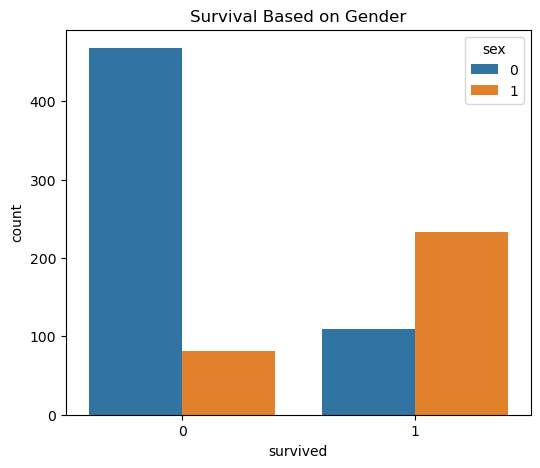

In [23]:
plt.figure(figsize=(6,5))

sns.countplot(
    x='survived',
    hue='sex',
    data=titanic
)

plt.title("Survival Based on Gender")

plt.savefig("survival_gender.png")

plt.show()

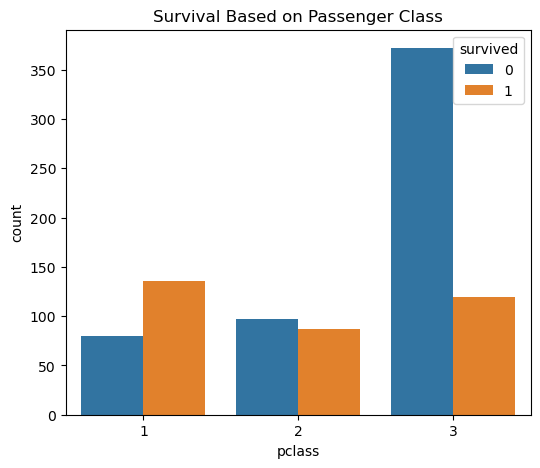

In [24]:
plt.figure(figsize=(6,5))

sns.countplot(
    x='pclass',
    hue='survived',
    data=titanic
)

plt.title("Survival Based on Passenger Class")

plt.savefig("survival_class.png")

plt.show()

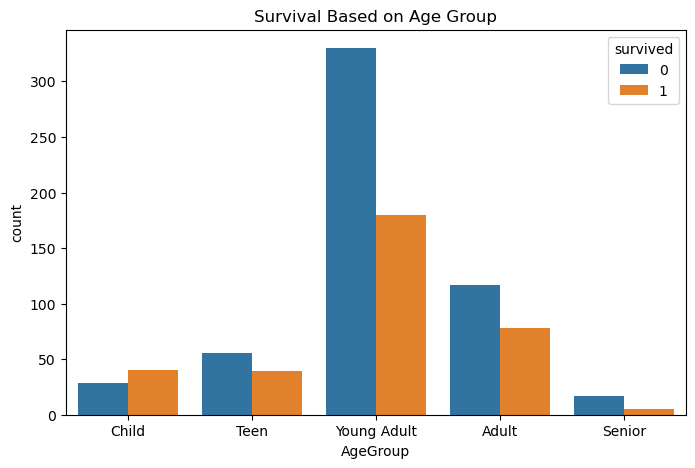

In [25]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='AgeGroup',
    hue='survived',
    data=titanic
)

plt.title("Survival Based on Age Group")

plt.savefig("survival_agegroup.png")

plt.show()

In [26]:
titanic['FamilySize'] = (
    titanic['sibsp']
    + titanic['parch']
    + 1
)

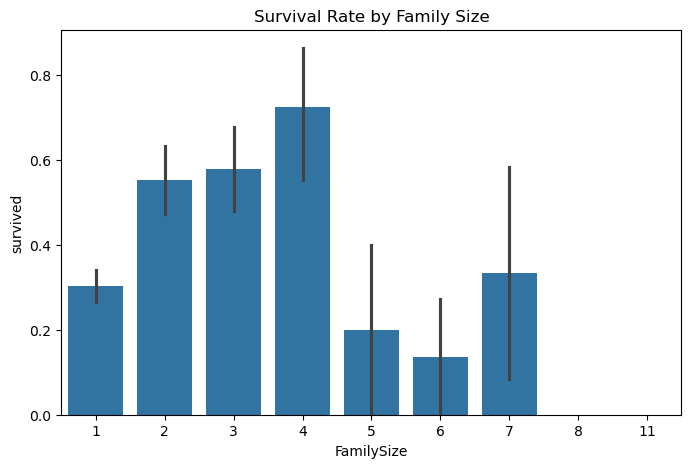

In [27]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='FamilySize',
    y='survived',
    data=titanic
)

plt.title("Survival Rate by Family Size")

plt.savefig("family_survival.png")

plt.show()

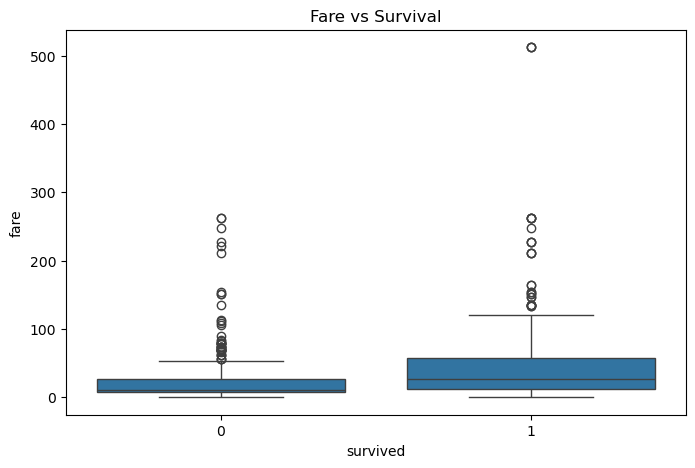

In [28]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='survived',
    y='fare',
    data=titanic
)

plt.title("Fare vs Survival")

plt.savefig("fare_survival.png")

plt.show()

In [29]:
gender_survival = titanic.groupby('sex')['survived'].mean()

print(gender_survival)

sex
0    0.188908
1    0.742038
Name: survived, dtype: float64


In [30]:
class_survival = titanic.groupby('pclass')['survived'].mean()

print(class_survival)

pclass
1    0.629630
2    0.472826
3    0.242363
Name: survived, dtype: float64


In [31]:
pivot = titanic.pivot_table(
    values='survived',
    index='pclass',
    columns='sex',
    aggfunc='mean'
)

print(pivot)

sex            0         1
pclass                    
1       0.368852  0.968085
2       0.157407  0.921053
3       0.135447  0.500000


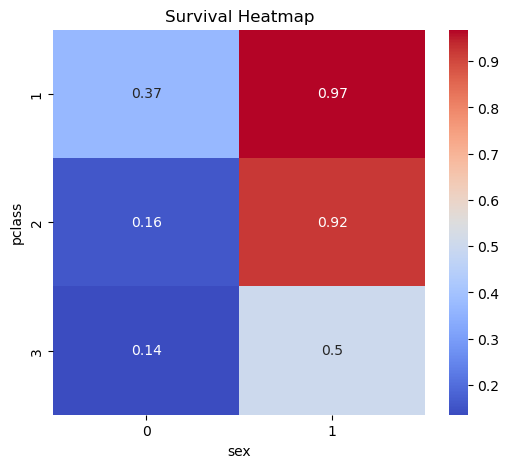

In [32]:
plt.figure(figsize=(6,5))

sns.heatmap(
    pivot,
    annot=True,
    cmap='coolwarm'
)

plt.title("Survival Heatmap")

plt.savefig("heatmap_survival.png")

plt.show()

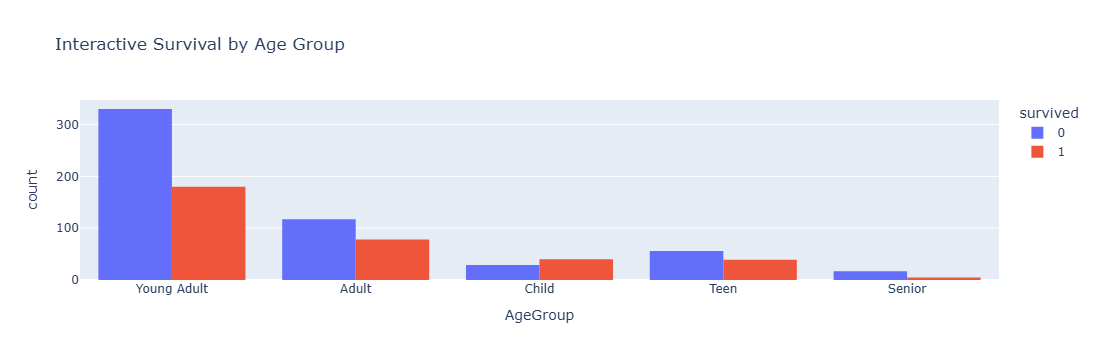

In [33]:
fig = px.histogram(
    titanic,
    x='AgeGroup',
    color='survived',
    barmode='group',
    title='Interactive Survival by Age Group'
)

fig.show()